In [ ]:
import os
os.environ['TORCHANI_NO_WARN_EXTENSIONS'] = '1'

import math
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchani
from torchani.nn._core import AtomicNetwork
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import copy
from tqdm.notebook import tqdm
from torch_geometric.datasets import MD17


In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True

MOLECULE_NAME = 'paracetamol'

N_TRAIN_LIST = [100, 500, 1000, 2000, 5000]
N_TEST = 5000
N_VAL = 2000

N_REPEATS = 7
MAX_EPOCHS = 5000
PATIENCE = 80

LR_TRAIN = 1e-3
CSV_FILENAME = f'metrics_md17_7reps_{MOLECULE_NAME}.csv'

BETA = 100.0

STRATEGIES = ['classic', 'auto-diff', 'gradient']

def get_batch_size(n_train):
    bs = max(16, min(128, n_train // 8))
    return 2 ** int(math.log2(bs))


In [ ]:
class EarlyStopping:
    def __init__(self, patience=20, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_weights = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_weights = copy.deepcopy(model.state_dict())
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_weights = copy.deepcopy(model.state_dict())
            self.counter = 0

class TorchANI2Model(nn.Module):
    def __init__(self, converter, aev_comp, nns):
        super().__init__()
        self.converter = converter
        self.aev_comp = aev_comp
        self.nns = nns
    def forward(self, atomic_numbers, coords):
        species_idx = self.converter(atomic_numbers)
        aevs = self.aev_comp(species_idx, coords)
        return self.nns(species_idx, aevs)

In [ ]:
print(f"Chargement de MD17 ({MOLECULE_NAME}) sur {DEVICE}...")
dataset = MD17(root='./data/MD17', name=MOLECULE_NAME)
print(f"Nombre total de configurations : {len(dataset)}")

z_raw = dataset[0].z.unsqueeze(0).to(DEVICE)
species_base = z_raw.clone()

R_full = torch.stack([data.pos for data in dataset]).to(DEVICE)
E_full = torch.stack([data.energy for data in dataset]).to(DEVICE)
F_full = torch.stack([data.force for data in dataset]).to(DEVICE)

indices = torch.randperm(len(R_full), generator=torch.Generator().manual_seed(42))
test_idx = indices[-N_TEST:]
val_idx = indices[-(N_TEST + N_VAL):-N_TEST]
train_pool_idx = indices[:-(N_TEST + N_VAL)]

species_te = species_base.repeat(N_TEST, 1)
R_te, E_te, F_te = R_full[test_idx], E_full[test_idx], F_full[test_idx]

species_val = species_base.repeat(N_VAL, 1)
R_val, E_val, F_val = R_full[val_idx], E_full[val_idx], F_full[val_idx]

print("Chargement de l'AEV")
_ref = torchani.models.ANI1x(periodic_table_index=True).to(DEVICE)
species_converter = _ref.species_converter
aev_computer = _ref.aev_computer
del _ref


Chargement de MD17 (paracetamol) sur cpu...


Processing...
Done!


Chargement de l'AEV


In [ ]:
results = []
mse_loss = nn.MSELoss()

print(f"\nDémarrage de l'étude ({len(STRATEGIES) * len(N_TRAIN_LIST) * N_REPEATS} entraînements prévus)")
print("  Batch sizes utilisés :", {n: get_batch_size(n) for n in N_TRAIN_LIST})

for n_train in N_TRAIN_LIST:
    batch_size = get_batch_size(n_train)
    print(f"\nENTRAÎNEMENT POUR N = {n_train} (batch_size={batch_size})")

    for strategy in STRATEGIES:
        print(f"\nStratégie en cours : {strategy.upper()}")

        for rep in tqdm(range(N_REPEATS), desc=f"Rép. ({strategy})"):

            torch.manual_seed(rep)
            rep_gen = torch.Generator().manual_seed(rep)

            rep_indices = torch.randperm(len(train_pool_idx), generator=rep_gen)[:n_train]
            current_train_idx = train_pool_idx[rep_indices]

            species_tr = species_base.repeat(n_train, 1)
            R_tr, E_tr, F_tr = R_full[current_train_idx], E_full[current_train_idx], F_full[current_train_idx]

            E_mean = E_tr.mean()
            E_tr_centered = E_tr - E_mean
            E_val_centered = E_val - E_mean
            E_te_centered = E_te - E_mean

            train_loader = torch.utils.data.DataLoader(
                torch.utils.data.TensorDataset(species_tr, R_tr, E_tr_centered, F_tr),
                batch_size=batch_size, shuffle=True
            )
            val_loader = torch.utils.data.DataLoader(
                torch.utils.data.TensorDataset(species_val, R_val, E_val_centered, F_val),
                batch_size=batch_size, shuffle=False
            )

            model = TorchANI2Model(
                species_converter, aev_computer,
                torchani.nn.ANINetworks({
                    'H': AtomicNetwork(layer_dims=(384, 160, 128, 96, 1), activation="celu", bias=True),
                    'C': AtomicNetwork(layer_dims=(384, 144, 112, 96, 1), activation="celu", bias=True),
                    'N': AtomicNetwork(layer_dims=(384, 128, 112, 96, 1), activation="celu", bias=True),
                    'O': AtomicNetwork(layer_dims=(384, 128, 112, 96, 1), activation="celu", bias=True),
                })
            ).to(DEVICE)

            weights, biases = [], []
            for name, param in model.named_parameters():
                if 'weight' in name: weights.append(param)
                elif 'bias' in name: biases.append(param)

            optimizer = optim.AdamW(
                [{'params': weights, 'weight_decay': 1e-4}, {'params': biases, 'weight_decay': 0.0}],
                lr=LR_TRAIN
            )
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20, threshold=1e-4)
            early_stopping = EarlyStopping(patience=PATIENCE, min_delta=1e-5)

            #boucle
            epochs_run = 0
            t_train_start = time.perf_counter()

            for epoch in range(MAX_EPOCHS):
                epochs_run += 1

                model.train()
                for batch_species, batch_R, batch_E, batch_F in train_loader:
                    optimizer.zero_grad(set_to_none=True)
                    if strategy in ['auto-diff', 'gradient']:
                        batch_R.requires_grad_(True)

                    preds_E = model(batch_species, batch_R)

                    if strategy == 'classic':
                        loss = mse_loss(preds_E.flatten(), batch_E.flatten())
                    elif strategy == 'auto-diff':
                        preds_F = -torch.autograd.grad(preds_E.sum(), batch_R, create_graph=True, retain_graph=True)[0]
                        loss = mse_loss(preds_E.flatten(), batch_E.flatten()) + BETA * mse_loss(preds_F.flatten(), batch_F.flatten())
                    elif strategy == 'gradient':
                        preds_F = -torch.autograd.grad(preds_E.sum(), batch_R, create_graph=True)[0]
                        loss = mse_loss(preds_F.flatten(), batch_F.flatten())

                    loss.backward()
                    optimizer.step()

                #val
                model.eval()
                epoch_val_loss = 0.0
                with torch.set_grad_enabled(True):
                    for v_s, v_R, v_E, v_F in val_loader:
                        v_R_req   = v_R.clone().detach().requires_grad_(True)
                        v_preds_E = model(v_s, v_R_req)

                        if strategy == 'classic':
                            v_loss = mse_loss(v_preds_E.flatten(), v_E.flatten())
                        elif strategy == 'auto-diff':
                            v_preds_F = -torch.autograd.grad(v_preds_E.sum(), v_R_req, create_graph=False)[0]
                            v_loss = mse_loss(v_preds_E.flatten(), v_E.flatten()) + BETA * mse_loss(v_preds_F.flatten(), v_F.flatten())
                        elif strategy == 'gradient':
                            v_preds_F = -torch.autograd.grad(v_preds_E.sum(), v_R_req, create_graph=False)[0]
                            v_loss = mse_loss(v_preds_F.flatten(), v_F.flatten())

                        epoch_val_loss += v_loss.item()

                epoch_val_loss /= len(val_loader)
                scheduler.step(epoch_val_loss)
                early_stopping(epoch_val_loss, model)
                if early_stopping.early_stop:
                    break

            if DEVICE.type == 'cuda':
                torch.cuda.synchronize()
            train_time_s = time.perf_counter() - t_train_start

            model.load_state_dict(early_stopping.best_weights)

            optimal_shift = 0.0
            if strategy == 'gradient':
                model.eval()
                with torch.no_grad():
                    all_preds_E_train, all_true_E_train = [], []
                    for b_s, b_R, b_E, _ in train_loader:
                        all_preds_E_train.append(model(b_s, b_R).flatten())
                        all_true_E_train.append(b_E.flatten())
                    optimal_shift = (torch.cat(all_true_E_train) - torch.cat(all_preds_E_train)).mean().item()

            #test
            model.eval()
            total_mae_E = total_mae_F = total_E_items = total_F_items = 0.0
            test_loader = torch.utils.data.DataLoader(
                torch.utils.data.TensorDataset(species_te, R_te, E_te_centered, F_te),
                batch_size=batch_size
            )
            with torch.set_grad_enabled(True):
                for b_species, b_R, b_E, b_F in test_loader:
                    b_R_req = b_R.clone().detach().requires_grad_(True)
                    b_preds_E = model(b_species, b_R_req)
                    b_pred_forces = -torch.autograd.grad(b_preds_E.sum(), b_R_req, create_graph=False)[0]
                    b_preds_E_corrected = b_preds_E + optimal_shift
                    total_mae_E += torch.abs(b_preds_E_corrected.flatten() - b_E.flatten()).sum().item()
                    total_mae_F += torch.abs(b_pred_forces - b_F).sum().item()
                    total_E_items += b_E.numel()
                    total_F_items += b_F.numel()

            results.append({
                "Strategy": strategy,
                "N_Train": n_train,
                "Batch_Size": batch_size,
                "Repetition": rep + 1,
                "Epochs_Run": epochs_run,
                "Train_Time_s": round(train_time_s, 2),
                "Time_per_Epoch_s": round(train_time_s / epochs_run, 4),
                "MAE_Energy": total_mae_E / total_E_items,
                "MAE_Force": total_mae_F / total_F_items,
            })

            #save
            pd.DataFrame(results).to_csv(CSV_FILENAME, index=False)



Démarrage de l'étude (105 entraînements prévus)
  Batch sizes utilisés : {100: 16, 500: 32, 1000: 64, 2000: 128, 5000: 128}

ENTRAÎNEMENT POUR N = 100 (batch_size=16)

Stratégie en cours : CLASSIC


Rép. (classic):   0%|          | 0/7 [00:00<?, ?it/s]


Stratégie en cours : AUTO-DIFF


Rép. (auto-diff):   0%|          | 0/7 [00:00<?, ?it/s]


💾 Résultats sauvegardés et chargés depuis 'metrics_md17_7reps_dashboard.csv'


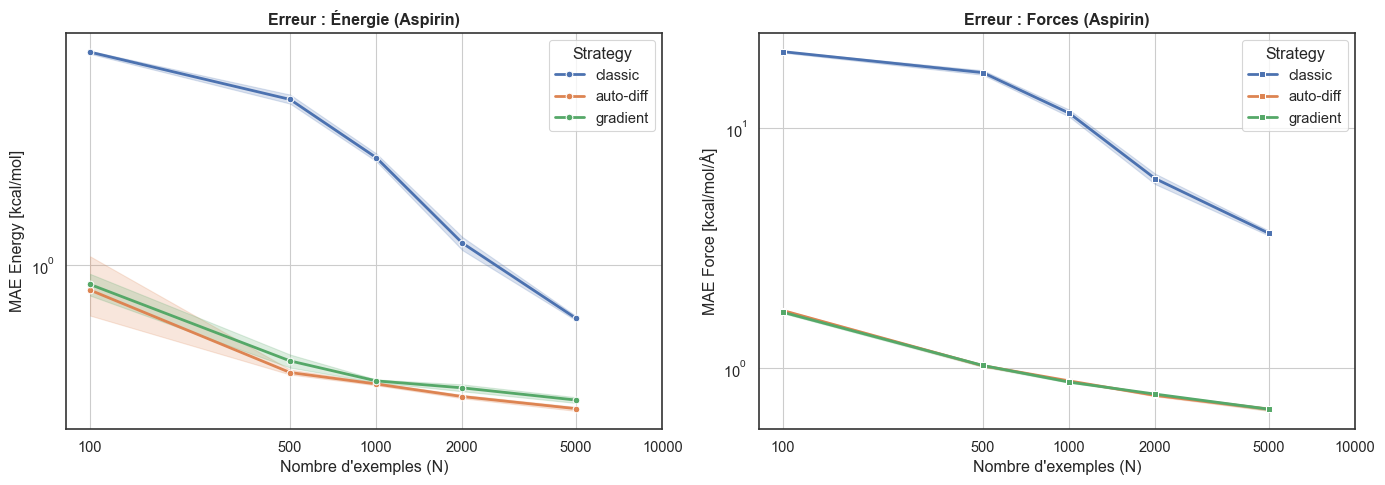

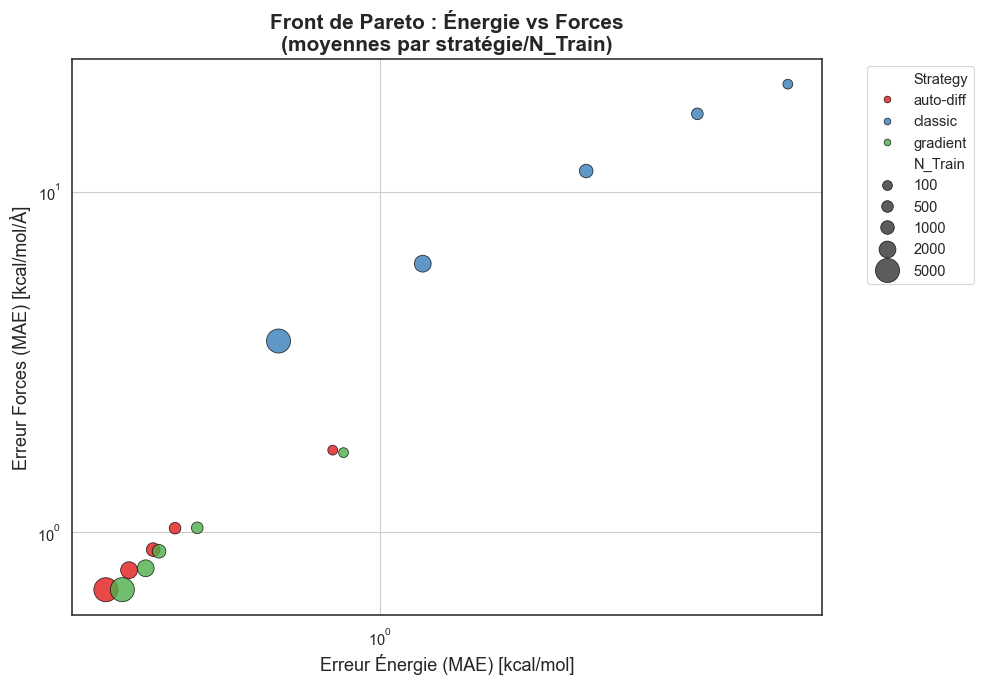

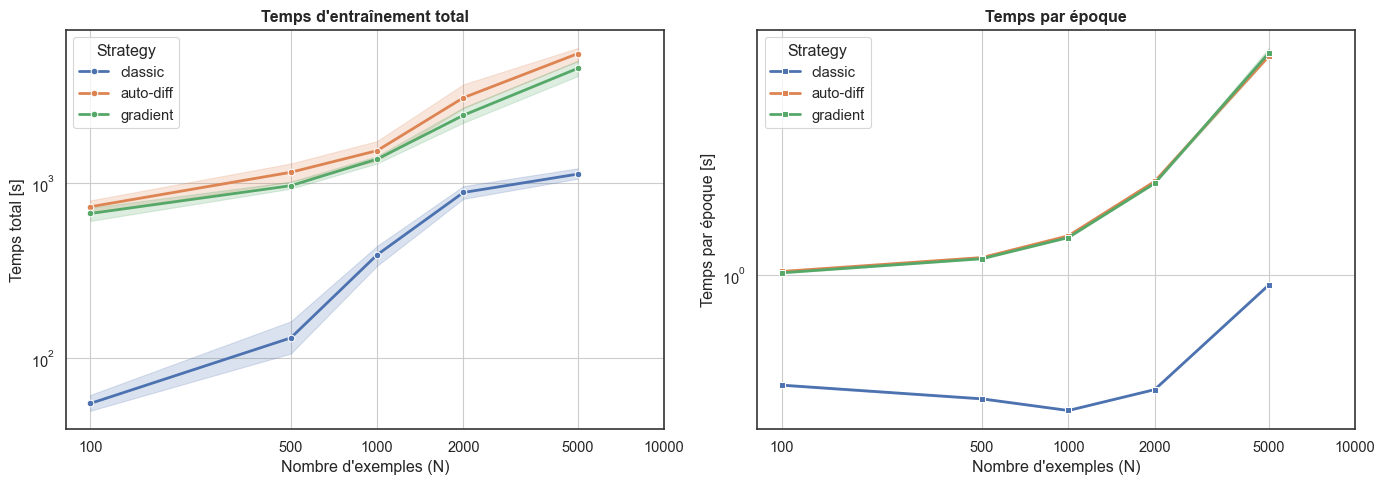

In [ ]:
df_res = pd.read_csv(CSV_FILENAME)
print(f"\nRésultats sauvegardés et chargés depuis '{CSV_FILENAME}'")

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2,
              rc={"axes.edgecolor": "0.2", "axes.linewidth": 1.2})

#fig 1
fig1, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=df_res, x='N_Train', y='MAE_Energy', hue='Strategy', marker='o', linewidth=2, ax=axes[0])
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xticks(N_TRAIN_LIST); axes[0].set_xticklabels(N_TRAIN_LIST)
axes[0].set_xlabel("Nombre d'exemples (N)")
axes[0].set_ylabel("MAE Energy [kcal/mol]")
axes[0].set_title(f"Erreur : Énergie ({MOLECULE_NAME.capitalize()})", fontweight='bold')

sns.lineplot(data=df_res, x='N_Train', y='MAE_Force', hue='Strategy', marker='s', linewidth=2, ax=axes[1])
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xticks(N_TRAIN_LIST); axes[1].set_xticklabels(N_TRAIN_LIST)
axes[1].set_xlabel("Nombre d'exemples (N)")
axes[1].set_ylabel("MAE Force [kcal/mol/Å]")
axes[1].set_title(f"Erreur : Forces ({MOLECULE_NAME.capitalize()})", fontweight='bold')
plt.tight_layout()
plt.show()

#fig 2
df_mean_pareto = df_res.groupby(['Strategy', 'N_Train'])[['MAE_Energy', 'MAE_Force']].mean().reset_index()

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_mean_pareto,
    x='MAE_Energy', y='MAE_Force',
    hue='Strategy', size='N_Train',
    sizes=(50, 300), alpha=0.8,
    palette='Set1', edgecolor='black'
)
plt.xscale('log'); plt.yscale('log')
plt.xlabel("Erreur Énergie (MAE) [kcal/mol]", fontsize=13)
plt.ylabel("Erreur Forces (MAE) [kcal/mol/Å]", fontsize=13)
plt.title("Front de Pareto : Énergie vs Forces\n(moyennes par stratégie/N_Train)", fontsize=15, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#fig 3
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=df_res, x='N_Train', y='Train_Time_s', hue='Strategy', marker='o', linewidth=2, ax=axes3[0])
axes3[0].set_xscale('log'); axes3[0].set_yscale('log')
axes3[0].set_xticks(N_TRAIN_LIST); axes3[0].set_xticklabels(N_TRAIN_LIST)
axes3[0].set_xlabel("Nombre d'exemples (N)")
axes3[0].set_ylabel("Temps total [s]")
axes3[0].set_title("Temps d'entraînement total", fontweight='bold')

sns.lineplot(data=df_res, x='N_Train', y='Time_per_Epoch_s', hue='Strategy', marker='s', linewidth=2, ax=axes3[1])
axes3[1].set_xscale('log'); axes3[1].set_yscale('log')
axes3[1].set_xticks(N_TRAIN_LIST); axes3[1].set_xticklabels(N_TRAIN_LIST)
axes3[1].set_xlabel("Nombre d'exemples (N)")
axes3[1].set_ylabel("Temps par époque [s]")
axes3[1].set_title("Temps par époque", fontweight='bold')
plt.tight_layout()
plt.show()